# About DataSet

The UGRansom dataset is a versatile resource for analyzing ransomware and zero-day cyberattacks. It provides timestamps, flags for attack types, protocol data, and network flow details. Additionally, it offers ransomware family classifications, malware insights, and quantifies financial damage in USD and bitcoins.

**The features in the dataset :**

1) Time: Timestamps of network attacks (quantitative).

2) Protocol: Network protocol used (categorical).

3) Flag: Network connection status (categorical).

4) Family: Category of network intrusion (categorical).

5) Clusters: Event clusters or groups (quantitative).

6) SeedAddress: Formatted ransomware attack links (categorical).

7) ExpAddress: Original ransomware attack links (categorical).

8) BTC: Values related to Bitcoin transactions in attacks (numeric).

9) USD: Financial damages in USD caused by attacks (numeric).

10) Netflow Bytes: Bytes transferred in network flow (quantitative).

11) IPaddress: IP addresses associated with network events (categorical).

12) Threats: Nature of threats or intrusions (categorical).

13) Port: Network port number in events (quantitative).

14) Prediction: Target variable indicating predictive model outcomes (anomaly (A), signature (S), and synthetic signature (SS)) (categorical).

# Importing Libraries


In [164]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report 
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

In [165]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nkongolo/ugransome-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\DEVANSHU K RANJAN\.cache\kagglehub\datasets\nkongolo\ugransome-dataset\versions\1


In [166]:
import os
data_path = os.path.join(path, "final(2).csv")
data=pd.read_csv(data_path)
data

,Time,Protcol,Flag,Family,Clusters,SeddAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port,Prediction
0,50,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,500,5,A,Bonet,5061,SS
1,40,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,504,8,A,Bonet,5061,SS
2,30,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,508,7,A,Bonet,5061,SS
3,20,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,512,15,A,Bonet,5061,SS
4,57,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,516,9,A,Bonet,5061,SS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149038,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1010,1590,3340,A,Scan,5062,A
149039,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1014,1596,3351,A,Scan,5062,A
149040,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1018,1602,3362,A,Scan,5062,A
149041,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1022,1608,3373,A,Scan,5062,A


In [167]:
import pandas as pd
df_benign = pd.read_csv("Dataset/unsw_benign_51k.csv")     # Generated benign dataset

# 🔄 Step 2: Combine them
df_combined = pd.concat([data, df_benign], ignore_index=True)

# 🧹 Step 3: Shuffle rows (optional but recommended)
df_combined = df_combined.sample(frac=1).reset_index(drop=True)

# 💾 Step 4: Save to new file
df_combined.to_csv("Dataset/combined_dataset.csv", index=False)

print("✅ combined_dataset.csv created with", len(df_combined), "rows!")

✅ combined_dataset.csv created with 200043 rows!


In [168]:
data=pd.read_csv("Dataset/combined_dataset.csv")

In [169]:
data.isnull().sum()

Time                 0
Protcol              0
Flag                 0
Family               0
Clusters             0
SeddAddress          0
ExpAddress           0
BTC                  0
USD                  0
Netflow_Bytes        0
IPaddress            0
Threats          51000
Port                 0
Prediction           0
dtype: int64

In [170]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,200043.0,16.253723,16.534453,-10.000000,1.000000,11.0,26.0,96.0
Clusters,200043.0,2.004124,2.545598,0.000000,1.000000,1.0,2.0,12.0
BTC,200043.0,22.764856,88.572359,0.000000,0.000000,9.0,20.0,1980.0
USD,200043.0,11074.843078,24063.462261,0.000203,3.945164,939.0,18197.0,126379.0
Netflow_Bytes,200043.0,10489.516669,73710.391227,1.000000,371.000000,1196.0,4081.0,2261056.0
Port,200043.0,4324.570367,2139.383383,53.000000,5061.000000,5062.0,5066.0,8080.0


In [171]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200043 entries, 0 to 200042
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Time           200043 non-null  float64
 1   Protcol        200043 non-null  object 
 2   Flag           200043 non-null  object 
 3   Family         200043 non-null  object 
 4   Clusters       200043 non-null  int64  
 5   SeddAddress    200043 non-null  object 
 6   ExpAddress     200043 non-null  object 
 7   BTC            200043 non-null  int64  
 8   USD            200043 non-null  float64
 9   Netflow_Bytes  200043 non-null  int64  
 10  IPaddress      200043 non-null  object 
 11  Threats        149043 non-null  object 
 12  Port           200043 non-null  int64  
 13  Prediction     200043 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 21.4+ MB


In [172]:
prediction_counts = data['Time'].value_counts()
prediction_counts

Time
20.000000    11393
1.000000      6845
7.000000      6359
10.000000     5193
4.000000      4848
             ...  
0.679189         1
1.723298         1
0.041963         1
0.033828         1
0.396347         1
Name: count, Length: 33632, dtype: int64

# Exploratory Data Analysis (EDA)

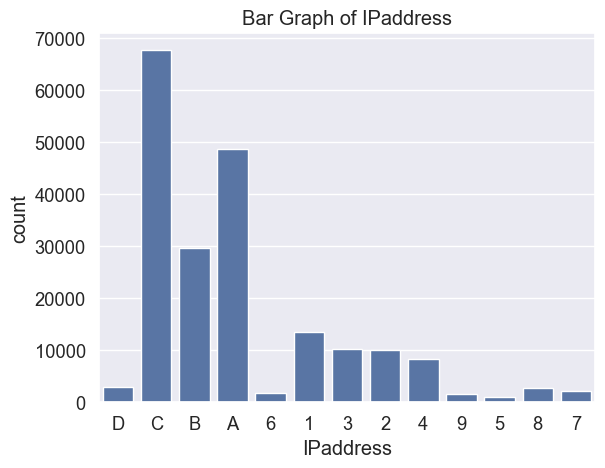

In [174]:
sns.countplot(x=data['IPaddress'], data=data)
plt.title('Bar Graph of IPaddress')
plt.show()

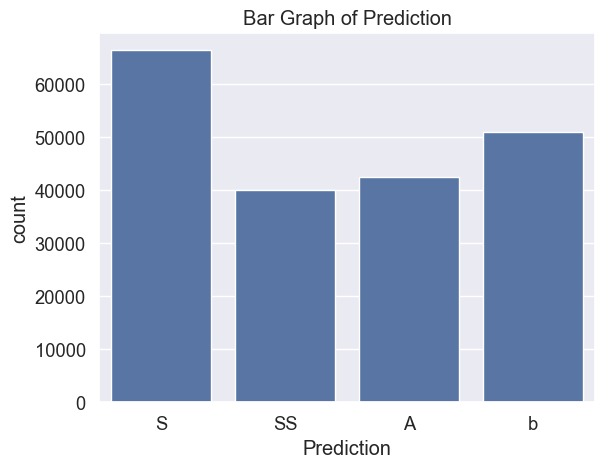

In [175]:
sns.countplot(x=data['Prediction'], data=data)
plt.title('Bar Graph of Prediction')
plt.show()

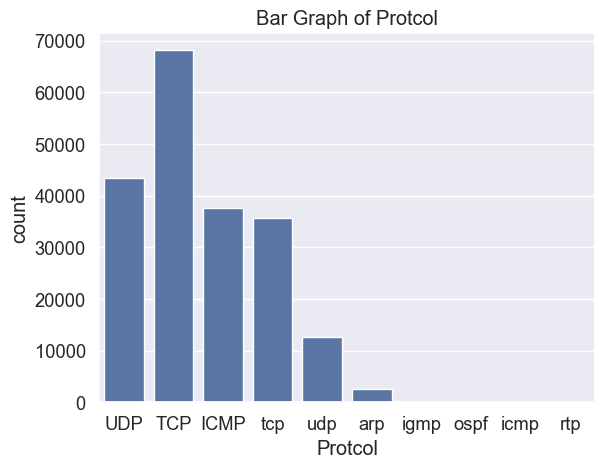

In [176]:
sns.countplot(x=data['Protcol'],data=data)
plt.title('Bar Graph of Protcol')
plt.show()

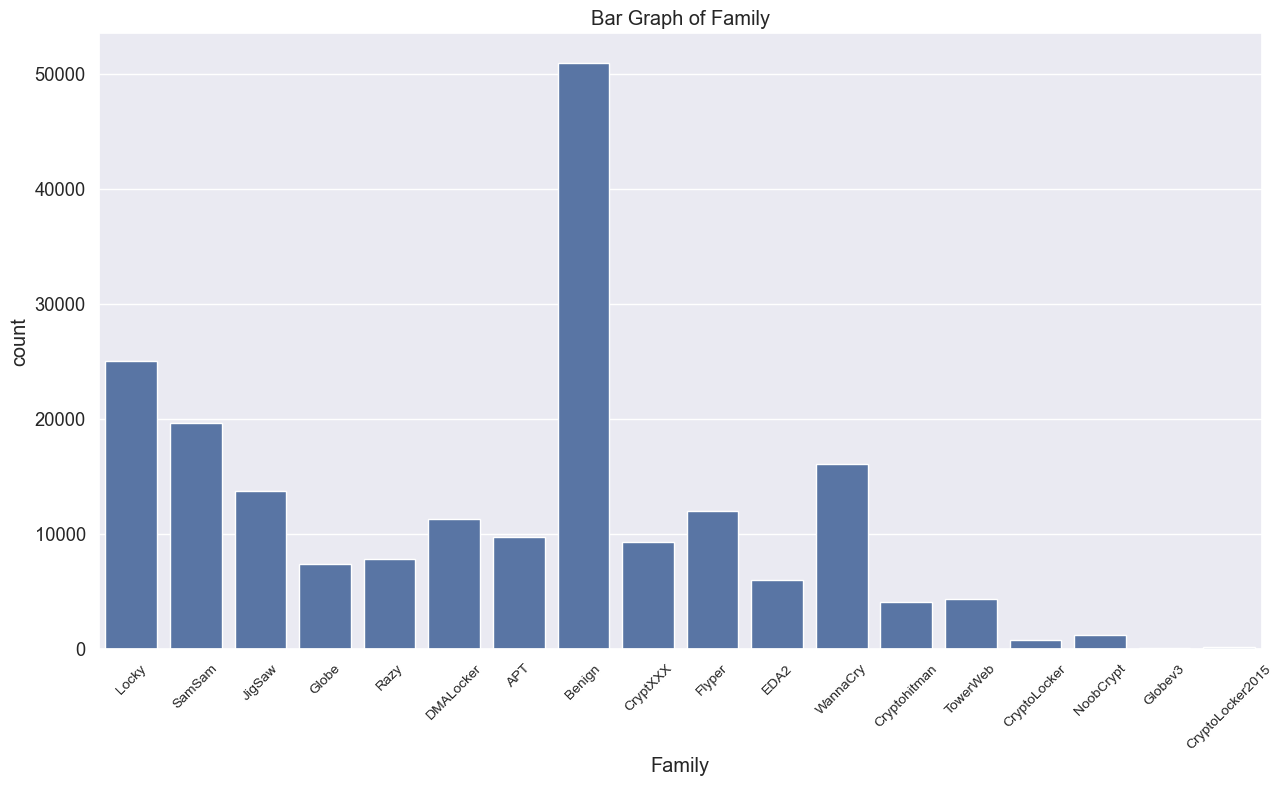

In [177]:
plt.figure(figsize=(15, 8))
ax = sns.countplot(x=data['Family'], data=data)
plt.title('Bar Graph of Family')
plt.xticks(rotation=45)
plt.xticks(fontsize=10)
plt.show()

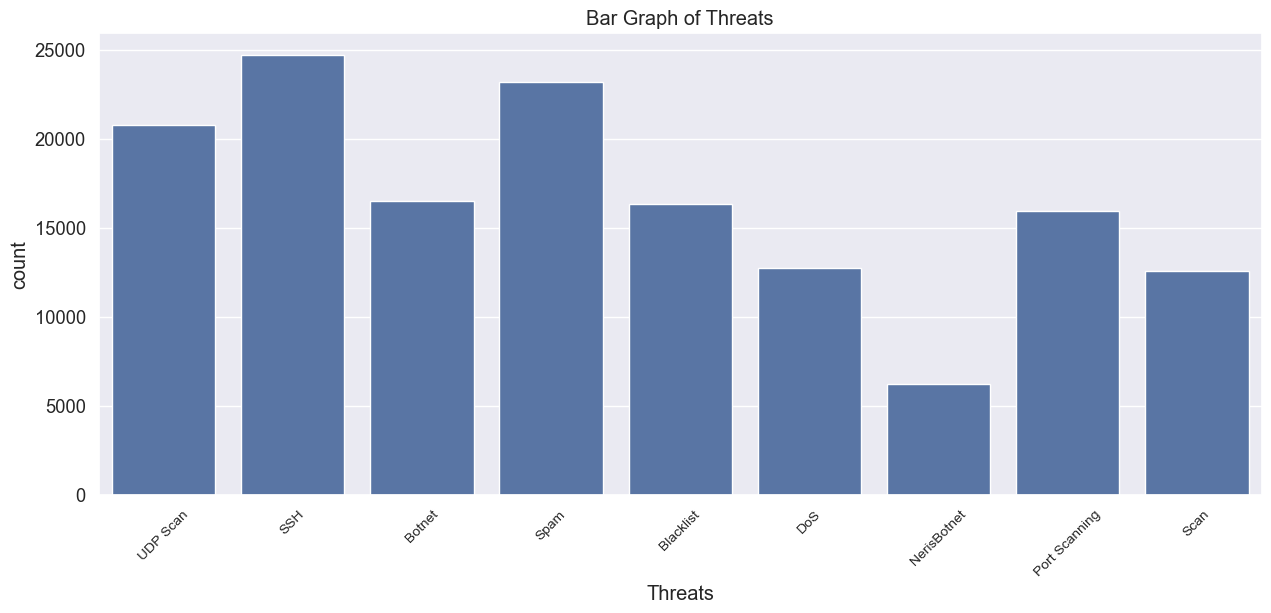

In [178]:
data['Threats'] = data['Threats'].str.replace('Bonet', 'Botnet')
plt.figure(figsize=(15, 6))
ax = sns.countplot(x=data['Threats'], data=data)
plt.title('Bar Graph of Threats')
plt.xticks(rotation=45)
plt.xticks(fontsize=10)
plt.show()

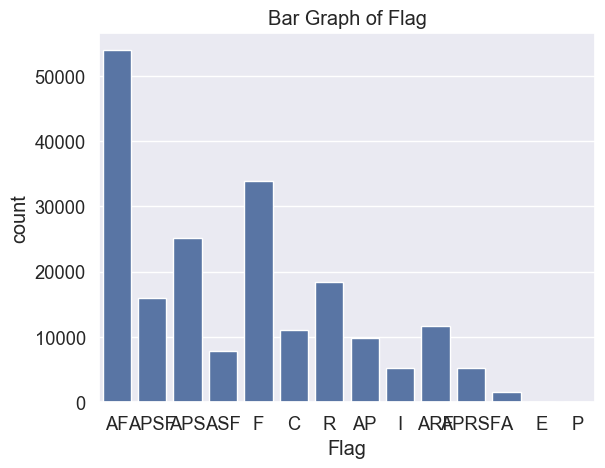

In [179]:
sns.countplot(x=data['Flag'],data=data)
plt.title('Bar Graph of Flag')
plt.show()

# Data Preprocessing

In [181]:
objList = data.select_dtypes(include = "object").columns
print (objList)

Index(['Protcol', 'Flag', 'Family', 'SeddAddress', 'ExpAddress', 'IPaddress',
       'Threats', 'Prediction'],
      dtype='object')


In [182]:
le = LabelEncoder()
label_map=[]
for feat in objList:
    data[feat] = le.fit_transform(data[feat].astype(str))
    if feat == 'Prediction':
        label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_map)

print (data.info())

Label Mapping: {'A': 0, 'S': 1, 'SS': 2, 'b': 3}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200043 entries, 0 to 200042
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Time           200043 non-null  float64
 1   Protcol        200043 non-null  int32  
 2   Flag           200043 non-null  int32  
 3   Family         200043 non-null  int32  
 4   Clusters       200043 non-null  int64  
 5   SeddAddress    200043 non-null  int32  
 6   ExpAddress     200043 non-null  int32  
 7   BTC            200043 non-null  int64  
 8   USD            200043 non-null  float64
 9   Netflow_Bytes  200043 non-null  int64  
 10  IPaddress      200043 non-null  int32  
 11  Threats        200043 non-null  int32  
 12  Port           200043 non-null  int64  
 13  Prediction     200043 non-null  int32  
dtypes: float64(2), int32(8), int64(4)
memory usage: 15.3 MB
None


In [183]:
data

,Time,Protcol,Flag,Family,Clusters,SeddAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port,Prediction
0,20.0,2,1,12,3,0,4,30,126379.0,1440,12,8,5068,1
1,5.0,1,5,15,1,2,4,2,1378.0,1178,11,5,5066,2
2,20.0,0,4,11,2,0,4,8,69.0,72,10,8,5061,0
3,20.0,2,4,9,2,0,4,147,234.0,363,9,1,5061,0
4,20.0,0,4,14,2,0,4,228,289.0,8256,10,7,5061,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200038,10.0,2,6,17,1,3,1,5,357.0,41,9,5,5066,2
200039,27.0,2,1,14,1,0,4,20,5507.0,1590,10,7,5061,1
200040,13.0,2,2,12,1,5,51006,19,18032.0,2636,11,7,5062,1
200041,19.0,2,1,14,11,0,4,87,409.0,582,11,3,5066,2


In [184]:
data.to_csv("Dataset/preprocesed_ransomware.csv", index=False)

In [185]:
# Required Libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load Dataset
df = pd.read_csv('Dataset/preprocesed_ransomware.csv')

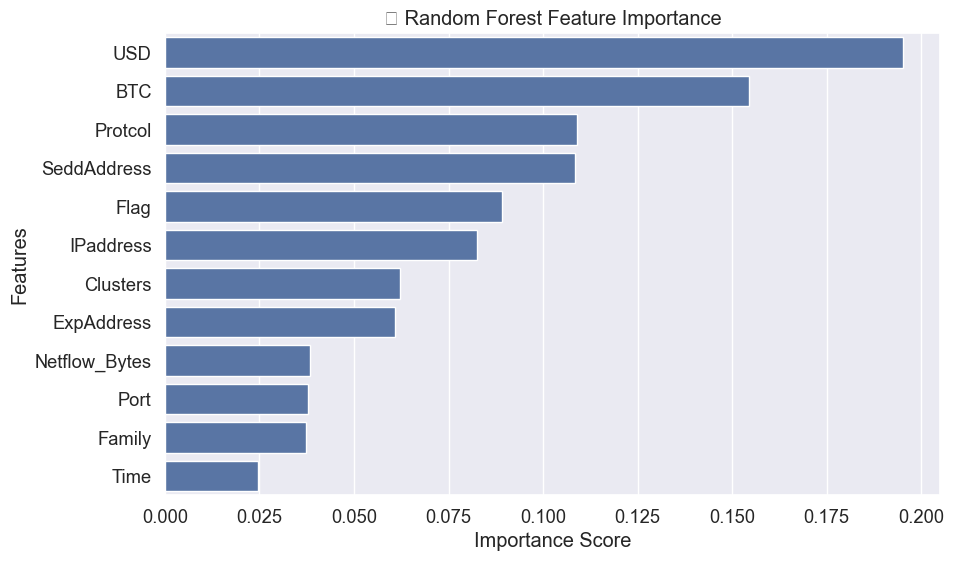

In [186]:
# Random Forest Feature Importance
X = df.drop(['Threats', 'Prediction'], axis=1)
y = df['Prediction']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_scores = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# 📊 Step 8: Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.title("🎯 Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [187]:
# 📝 Final Selected Features (Top N, e.g., Top 8)
top_features = feature_scores.head(10).index.tolist()
print(f"\n✅ Final Selected Features for Model Training:\n{top_features}")


✅ Final Selected Features for Model Training:
['USD', 'BTC', 'Protcol', 'SeddAddress', 'Flag', 'IPaddress', 'Clusters', 'ExpAddress', 'Netflow_Bytes', 'Port']


In [188]:
# Create a new DataFrame with only the top features and the target
df_top = df[top_features + ['Prediction']]

In [189]:
# Save to CSV
df_top.to_csv('Dataset/feature_selection.csv', index=False)

print("✅ Saved DataFrame with top features to: Dataset/feature_selection.csv")

✅ Saved DataFrame with top features to: Dataset/feature_selection.csv


In [190]:
# Load Dataset
data = pd.read_csv('Dataset/feature_selection.csv')

X=data.drop(['Prediction'],axis=1)
y=data['Prediction']

# Standardization of Features

In [192]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split

In [194]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training Set - X_train shape:", X_train.shape)
print("Testing Set - X_test shape:", X_test.shape)
print("Training Set - y_train shape:", y_train.shape)
print("Testing Set - y_test shape:", y_test.shape)

Training Set - X_train shape: (140030, 10)
Testing Set - X_test shape: (60013, 10)
Training Set - y_train shape: (140030,)
Testing Set - y_test shape: (60013,)


In [195]:
import pandas as pd
import numpy as np

# If using pandas DataFrame for X
if isinstance(X, pd.DataFrame):
    df_test = X_test.copy()
    df_test['label'] = y_test
else:
    # For NumPy arrays
    y_col = y_test.values.reshape(-1, 1)  # reshaping if needed
    combined = np.hstack((X_test, y_col))
    columns = top_features + ['label']
    df_test = pd.DataFrame(combined, columns=columns)

# Save to CSV
df_test.to_csv("Dataset/X_test_with_labels.csv", index=False)
print("✅ Test set saved as 'X_test_with_labels.csv'")


✅ Test set saved as 'X_test_with_labels.csv'


In [196]:
import numpy as np

# Save
np.savez_compressed("Dataset/train_test_split.npz",
                    X_train=X_train,
                    X_test=X_test,
                    y_train=y_train,
                    y_test=y_test)

print("✅ Train-test split saved as 'Dataset/train_test_split.npz'")

✅ Train-test split saved as 'Dataset/train_test_split.npz'


# Naive Bayes Model

In [198]:
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(nb_pred, y_test)
nb_report = classification_report(nb_pred, y_test)
nb_matrix = confusion_matrix(nb_pred, y_test)
print('Accuracy of Naive Bayes : ', round(nb_accuracy, 3))
print('Classification report of Naive Bayes : \n', nb_report)

Accuracy of Naive Bayes :  0.741
Classification report of Naive Bayes : 
               precision    recall  f1-score   support

           0       0.32      0.67      0.43      6078
           1       0.71      0.93      0.81     15320
           2       0.90      0.47      0.61     23329
           3       1.00      1.00      1.00     15286

    accuracy                           0.74     60013
   macro avg       0.73      0.77      0.71     60013
weighted avg       0.82      0.74      0.74     60013



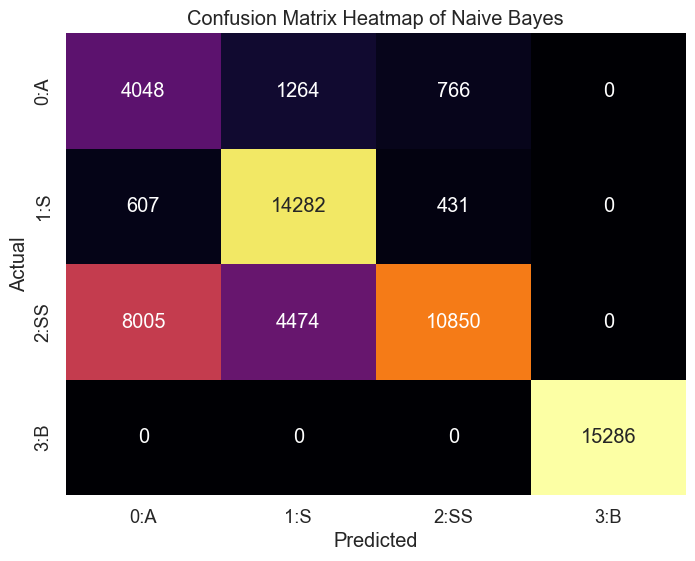

In [199]:
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  
sns.heatmap(nb_matrix, annot=True, fmt="d", cmap="inferno", cbar=False,
            xticklabels=["0:A", "1:S", "2:SS", "3:B"], yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap of Naive Bayes")
plt.show()

In [200]:
# FP = Total predicted as a class but were actually something else
false_positives_per_class = nb_matrix.sum(axis=0) - np.diag(nb_matrix)
nb_tfp = false_positives_per_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    print(f"  ➤ Class {i} (Label: {'A' if i==0 else 'S' if i==1 else 'SS' if i==2 else 'B'}): {fp}")

print("\n❗ Total False Positives in Model:", nb_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 8612
  ➤ Class 1 (Label: S): 5738
  ➤ Class 2 (Label: SS): 1197
  ➤ Class 3 (Label: B): 0

❗ Total False Positives in Model: 15547


In [201]:
import joblib

# Save the model
joblib.dump(nb, 'Model/nb_model.pkl')

['Model/nb_model.pkl']

# SVM Model

In [203]:
svr =SVC()
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)
svr_accuracy = accuracy_score(svr_pred, y_test)
svr_report = classification_report(svr_pred, y_test)
svr_matrix = confusion_matrix(svr_pred, y_test)
print('Accuracy of SVM : ', round(svr_accuracy, 3))
print('Classification report of SVM : \n', svr_report)

Accuracy of SVM :  0.945
Classification report of SVM : 
               precision    recall  f1-score   support

           0       0.88      0.89      0.88     12504
           1       0.96      0.95      0.95     20229
           2       0.93      0.93      0.93     11994
           3       1.00      1.00      1.00     15286

    accuracy                           0.95     60013
   macro avg       0.94      0.94      0.94     60013
weighted avg       0.95      0.95      0.95     60013



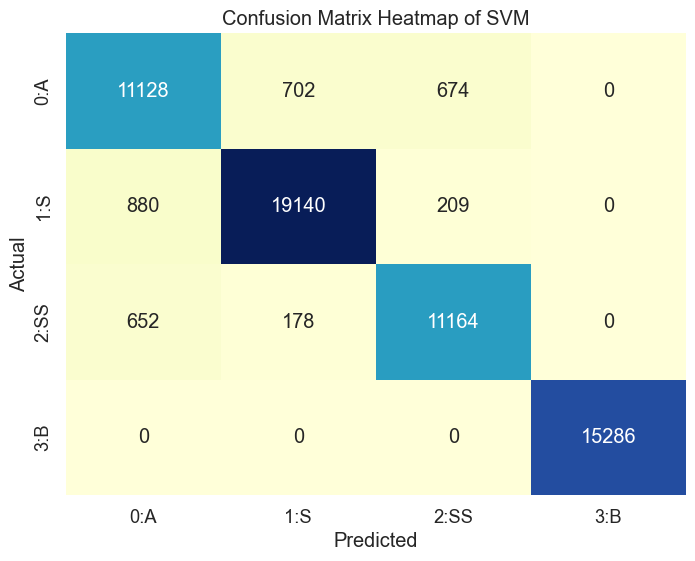

In [204]:
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  
sns.heatmap(svr_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
            xticklabels=["0:A", "1:S", "2:SS", "3:B"], yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap of SVM")
plt.show()

In [205]:
# FP = Total predicted as a class but were actually something else
false_positives_per_class = svr_matrix.sum(axis=0) - np.diag(svr_matrix)
svr_tfp = false_positives_per_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    print(f"  ➤ Class {i} (Label: {'A' if i==0 else 'S' if i==1 else 'SS' if i==2 else 'B'}): {fp}")

print("\n❗ Total False Positives in Model:", svr_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 1532
  ➤ Class 1 (Label: S): 880
  ➤ Class 2 (Label: SS): 883
  ➤ Class 3 (Label: B): 0

❗ Total False Positives in Model: 3295


In [206]:
import joblib

# Save the model
joblib.dump(svr, 'Model/svm_model.pkl')

['Model/svm_model.pkl']

# ANN MODEL

In [208]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="selu"), 
    layers.Dense(32, activation='selu'),
    layers.Dense(16, activation='selu'),
    layers.Dense(4, activation="softmax")  
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

history = model.fit(X_train, y_train, epochs=50, batch_size=16, 
                    callbacks=[early_stopping], validation_split=0.2)

Epoch 1/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.8901 - loss: 0.2937 - val_accuracy: 0.9489 - val_loss: 0.1339
Epoch 2/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9511 - loss: 0.1325 - val_accuracy: 0.9573 - val_loss: 0.1142
Epoch 3/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9549 - loss: 0.1215 - val_accuracy: 0.9572 - val_loss: 0.1131
Epoch 4/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9568 - loss: 0.1142 - val_accuracy: 0.9563 - val_loss: 0.1136
Epoch 5/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9593 - loss: 0.1063 - val_accuracy: 0.9625 - val_loss: 0.0976
Epoch 6/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9607 - loss: 0.0997 - val_accuracy: 0.9597 - val_loss: 0.0991
Epoch 7/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9609 - loss: 0.0993 - val_accuracy: 0.9552 - val_loss: 0.0931
Epoch 8/50
7002/7002 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.9622 - loss: 0

In [209]:
test_loss, ann_accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", round(ann_accuracy, 3))

y_pred = model.predict(X_test)
y_pred_class = np.argmax(y_pred, axis=1)
print(y_pred_class)

1876/1876 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9693 - loss: 0.0807
Test accuracy: 0.968
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
[0 3 0 ... 1 2 0]


In [210]:
class_report = classification_report(y_test, y_pred_class)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     12660
           1       0.97      0.97      0.97     20020
           2       0.96      0.97      0.96     12047
           3       1.00      1.00      1.00     15286

    accuracy                           0.97     60013
   macro avg       0.97      0.97      0.97     60013
weighted avg       0.97      0.97      0.97     60013



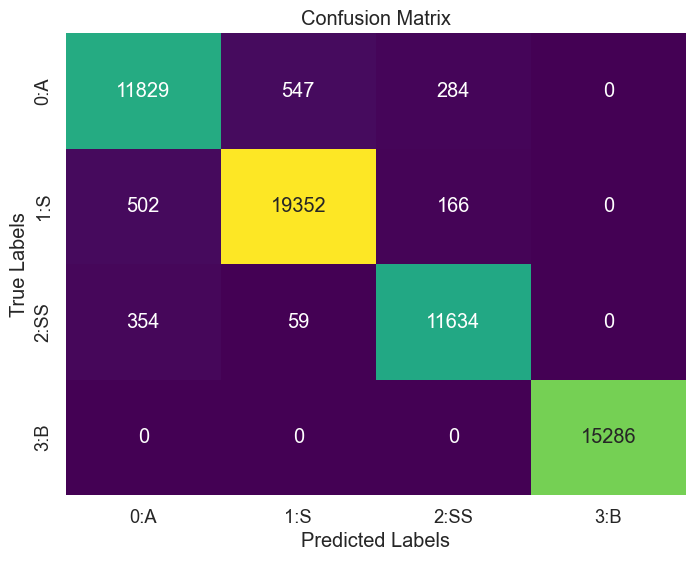

In [211]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis', cbar=False,
            xticklabels=["0:A", "1:S", "2:SS", "3:B"], yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [212]:
# False Positives per class: sum of column minus diagonal
false_positives_per_class = conf_matrix.sum(axis=0) - np.diag(conf_matrix)

# Total False Positives
ann_tfp = false_positives_per_class.sum()

# Display
print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    print(f"  ➤ Class {i} (Label: {'A' if i==0 else 'S' if i==1 else 'SS' if i==2 else 'B'}): {fp}")

print("\n❗ Total False Positives:", ann_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 856
  ➤ Class 1 (Label: S): 606
  ➤ Class 2 (Label: SS): 450
  ➤ Class 3 (Label: B): 0

❗ Total False Positives: 1912


In [213]:
# Save the full model
model.save("Model/ann_model.keras")

# RandomForestClassifier Model

In [215]:
rfc=RandomForestClassifier()
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)

rfc_accuracy = accuracy_score(rfc_pred, y_test)
rfc_report = classification_report(rfc_pred, y_test)
rfc_matrix = confusion_matrix(rfc_pred, y_test)
print('Accuracy of RandomForestClassifier : ', rfc_accuracy)
print('Classification report of RandomForestClassifier : \n', rfc_report)

Accuracy of RandomForestClassifier :  0.9857364237748488
Classification report of RandomForestClassifier : 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     12373
           1       0.98      0.98      0.98     20017
           2       1.00      0.97      0.98     12337
           3       1.00      1.00      1.00     15286

    accuracy                           0.99     60013
   macro avg       0.99      0.99      0.99     60013
weighted avg       0.99      0.99      0.99     60013



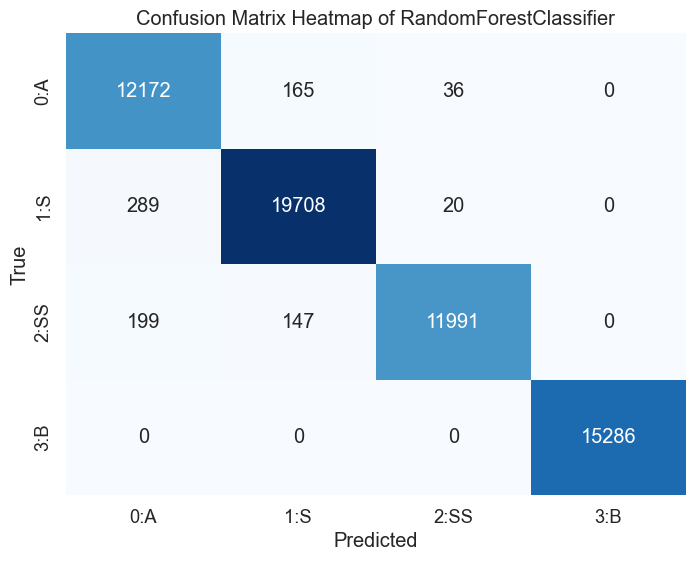

In [216]:
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  
sns.heatmap(rfc_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["0:A", "1:S", "2:SS", "3:B"], yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap of RandomForestClassifier")
plt.show()

In [217]:
# FP = Total predicted as a class but were actually something else
false_positives_per_class = rfc_matrix.sum(axis=0) - np.diag(rfc_matrix)
rfc_tfp = false_positives_per_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    print(f"  ➤ Class {i} (Label: {'A' if i==0 else 'S' if i==1 else 'SS' if i==2 else 'B'}): {fp}")

print("\n❗ Total False Positives in Model:", rfc_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 488
  ➤ Class 1 (Label: S): 312
  ➤ Class 2 (Label: SS): 56
  ➤ Class 3 (Label: B): 0

❗ Total False Positives in Model: 856


In [218]:
import joblib

# Save the model
joblib.dump(rfc, 'Model/rfc_model.pkl')

['Model/rfc_model.pkl']

# Gradient Boosting Model

In [220]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)
gbc_pred = gbc.predict(X_test)
gbc_accuracy = accuracy_score(y_test, gbc_pred)
gbc_report = classification_report(y_test, gbc_pred)
gbc_matrix = confusion_matrix(y_test, gbc_pred)

print('Accuracy of GradientBoostingClassifier:', gbc_accuracy)
print('Classification report of GradientBoostingClassifier:\n', gbc_report)

Accuracy of GradientBoostingClassifier: 0.9809707896622398
Classification report of GradientBoostingClassifier:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     12660
           1       0.98      0.98      0.98     20020
           2       0.97      0.99      0.98     12047
           3       1.00      1.00      1.00     15286

    accuracy                           0.98     60013
   macro avg       0.98      0.98      0.98     60013
weighted avg       0.98      0.98      0.98     60013



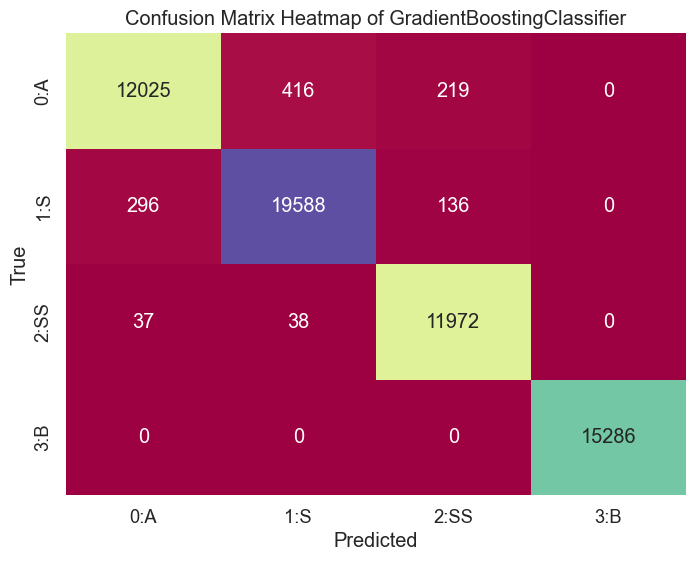

In [221]:
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  
sns.heatmap(gbc_matrix, annot=True, fmt="d", cmap="Spectral", cbar=False,
            xticklabels=["0:A", "1:S", "2:SS", "3:B"], yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap of GradientBoostingClassifier")
plt.show()

In [222]:
# FP = Total predicted as a class but were actually something else
false_positives_per_class = gbc_matrix.sum(axis=0) - np.diag(gbc_matrix)
gbc_tfp = false_positives_per_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    print(f"  ➤ Class {i} (Label: {'A' if i==0 else 'S' if i==1 else 'SS' if i==2 else 'B'}): {fp}")

print("\n❗ Total False Positives in Model:", gbc_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 333
  ➤ Class 1 (Label: S): 454
  ➤ Class 2 (Label: SS): 355
  ➤ Class 3 (Label: B): 0

❗ Total False Positives in Model: 1142


In [223]:
import joblib

# Save the model
joblib.dump(gbc, 'Model/gbc_model.pkl')

['Model/gbc_model.pkl']

# XGBoostClassifier

In [225]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("Accuracy of XGBoostClassifier:", xgb_accuracy)

print('Classification report of XGBoostClassifier:')
print(classification_report(y_test, y_pred_xgb))

Accuracy of XGBoostClassifier: 0.9828703780847483
Classification report of XGBoostClassifier:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     12660
           1       0.98      0.98      0.98     20020
           2       0.97      1.00      0.98     12047
           3       1.00      1.00      1.00     15286

    accuracy                           0.98     60013
   macro avg       0.98      0.98      0.98     60013
weighted avg       0.98      0.98      0.98     60013



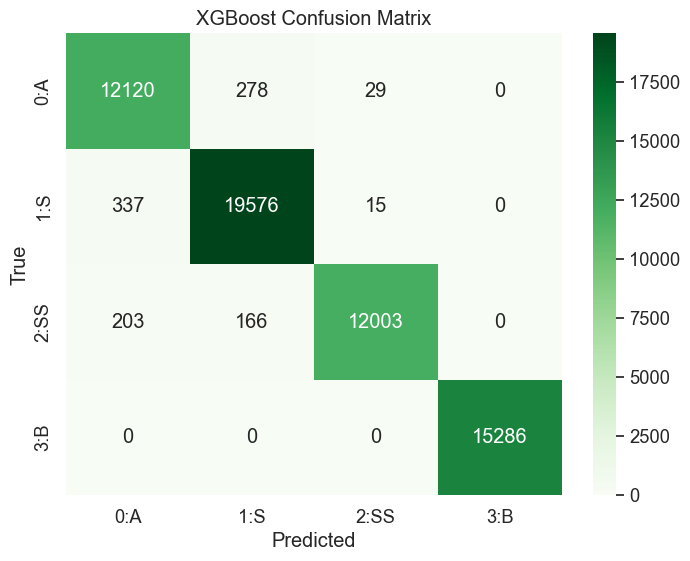

In [226]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

matrix = confusion_matrix(y_pred_xgb , y_test)
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=["0:A", "1:S", "2:SS", "3:B"], yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [227]:
# FP = Total predicted as a class but were actually something else
false_positives_per_class = matrix.sum(axis=0) - np.diag(matrix)
xgb_tfp = false_positives_per_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    print(f"  ➤ Class {i} (Label: {'A' if i==0 else 'S' if i==1 else 'SS' if i==2 else 'B'}): {fp}")

print("\n❗ Total False Positives in Model:", xgb_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 540
  ➤ Class 1 (Label: S): 444
  ➤ Class 2 (Label: SS): 44
  ➤ Class 3 (Label: B): 0

❗ Total False Positives in Model: 1028


In [228]:
import joblib

# Save the model
joblib.dump(xgb, 'Model/xgb_model.pkl')

['Model/xgb_model.pkl']

# Tab2Image_CNN Model

In [230]:
from tensorflow.keras.models import load_model
# ✅ Load CNN model
cnn2i_model = load_model("Model/cnn2image_model.keras")

In [231]:
# ✅ Convert Tabular to Image Format
def tabular_to_image(X, img_size=(64, 64)):
    total_pixels = img_size[0] * img_size[1]
    padded = np.zeros((X.shape[0], total_pixels))
    padded[:, :X.shape[1]] = X
    images = padded.reshape(-1, img_size[0], img_size[1], 1)
    return images

X_test_img = tabular_to_image(X_test)

In [232]:
np.save("Dataset/X_test_img.npy", X_test_img)

In [233]:
# Evaluation
test_loss_cnn2i, cnn2i_accuracy = cnn2i_model.evaluate(X_test_img, y_test)
print("Test accuracy:", cnn2i_accuracy)

1876/1876 ━━━━━━━━━━━━━━━━━━━━ 211s 112ms/step - accuracy: 0.9702 - loss: 0.0744
Test accuracy: 0.9686567783355713


1876/1876 ━━━━━━━━━━━━━━━━━━━━ 209s 111ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     12660
           1       0.97      0.97      0.97     20020
           2       0.96      0.97      0.96     12047
           3       1.00      1.00      1.00     15286

    accuracy                           0.97     60013
   macro avg       0.97      0.97      0.97     60013
weighted avg       0.97      0.97      0.97     60013



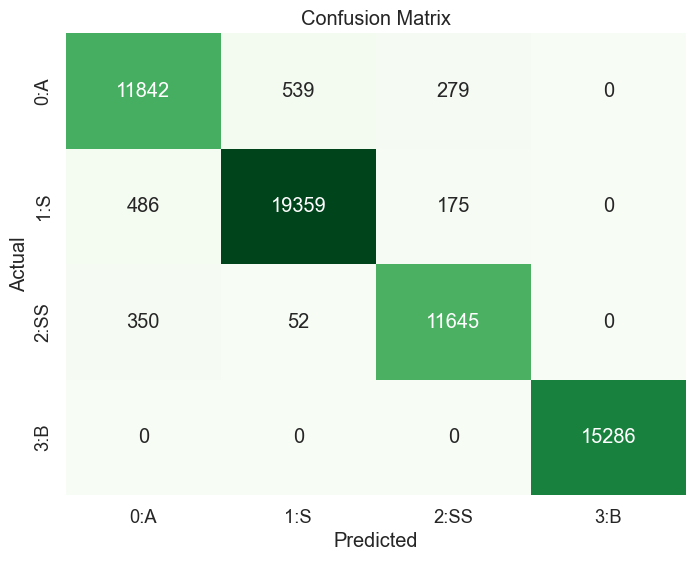

In [234]:
# ✅ Predict and Report
y_pred = cnn2i_model.predict(X_test_img)
y_pred_class = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_class))

# ✅ Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=["0:A", "1:S", "2:SS", "3:B"],
            yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [235]:
# ✅ False Positives
fp_per_class = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
cnn2i_tfp = fp_per_class.sum()
print("\n\U0001F6A8 False Positives per Class:")
for i, fp in enumerate(fp_per_class):
    label = ['A', 'S', 'SS', 'B'][i]
    print(f"  \u27a4 Class {i} (Label: {label}): {fp}")
print("\n❗ Total False Positives:", cnn2i_tfp)


🚨 False Positives per Class:
  ➤ Class 0 (Label: A): 836
  ➤ Class 1 (Label: S): 591
  ➤ Class 2 (Label: SS): 454
  ➤ Class 3 (Label: B): 0

❗ Total False Positives: 1881


# ML_EnsembleNet

In [237]:
rf_model = joblib.load("Model/rfc_model.pkl")
xgb_model = joblib.load("Model/xgb_model.pkl")
gbc_model = joblib.load("Model/gbc_model.pkl")

ml_ensemble_probs = (rf_model.predict_proba(X_test) +
                 xgb_model.predict_proba(X_test) +
                 gbc_model.predict_proba(X_test)) / 3
ensemble_preds = np.argmax(ml_ensemble_probs, axis=1)

In [238]:
# 📈 Accuracy
mle_accuracy = accuracy_score(y_test, ensemble_preds)
print("✅ ML Ensemble Accuracy:", mle_accuracy)

# 📄 Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, ensemble_preds))

✅ ML Ensemble Accuracy: 0.9859363804509023

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     12660
           1       0.98      0.98      0.98     20020
           2       0.97      1.00      0.98     12047
           3       1.00      1.00      1.00     15286

    accuracy                           0.99     60013
   macro avg       0.99      0.99      0.99     60013
weighted avg       0.99      0.99      0.99     60013



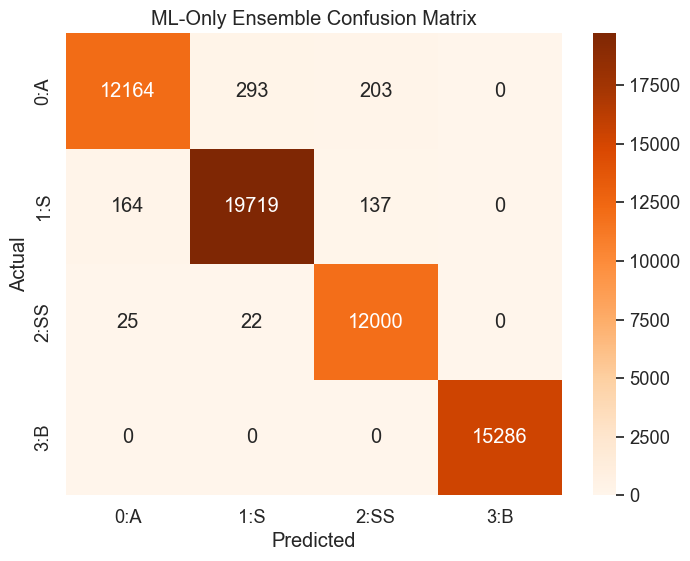

In [239]:
# 📊 Confusion Matrix
cm = confusion_matrix(y_test, ensemble_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Oranges", fmt='d',
            xticklabels=["0:A", "1:S", "2:SS", "3:B"],
            yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ML-Only Ensemble Confusion Matrix")
plt.show()


In [240]:
# 🚨 False Positives
fp_class = cm.sum(axis=0) - np.diag(cm)
mle_tfp = fp_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(fp_class):
    label = ['A', 'S', 'SS', 'B'][i]
    print(f"  ➤ Class {i} (Label: {label}): {fp}")
print("\n❗ Total False Positives:", mle_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 189
  ➤ Class 1 (Label: S): 315
  ➤ Class 2 (Label: SS): 340
  ➤ Class 3 (Label: B): 0

❗ Total False Positives: 844


# CNN-MLEnsembleNet Model

In [242]:
cnn_ensemble_preds = y_pred

In [243]:
# ✅ Final prediction: average ML + CNN
ensemble_test_probs = (ml_ensemble_probs + cnn_ensemble_preds) / 2

final_pred = np.argmax(ensemble_test_probs, axis=1)


✅ CNN-MLEnsembleNet Accuracy: 0.9834369220002332

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     12660
           1       0.98      0.98      0.98     20020
           2       0.97      1.00      0.98     12047
           3       1.00      1.00      1.00     15286

    accuracy                           0.98     60013
   macro avg       0.98      0.98      0.98     60013
weighted avg       0.98      0.98      0.98     60013



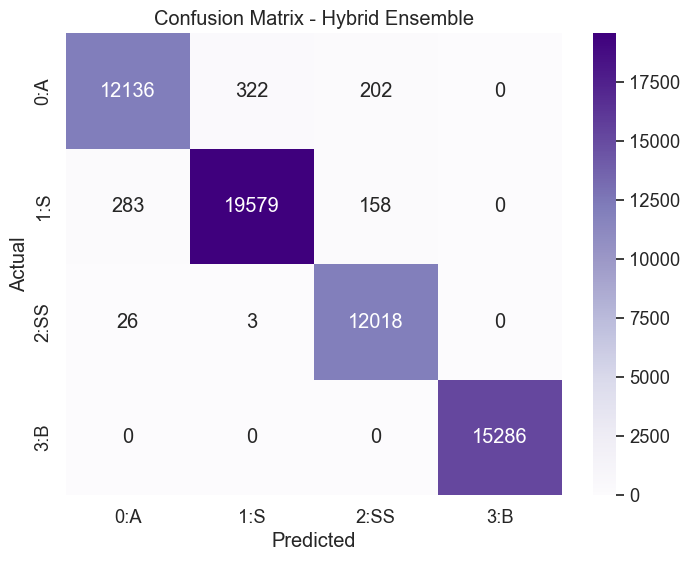

In [244]:
# ✅ Evaluate
cnn_ml_accuracy = accuracy_score(y_test, final_pred)
print("\n✅ CNN-MLEnsembleNet Accuracy:", cnn_ml_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, final_pred))

conf_matrix = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples',
            xticklabels=["0:A", "1:S", "2:SS", "3:B"],
            yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid Ensemble")
plt.show()

In [245]:
# ✅ False Positives Calculation
false_positives_per_class = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
cnn_ml_tfp = false_positives_per_class.sum()

print("\n🚨 False Positives Per Class:")
for i, fp in enumerate(false_positives_per_class):
    label = ['A', 'S', 'SS', 'B'][i]
    print(f"  ➤ Class {i} (Label: {label}): {fp}")

print("\n❗ Total False Positives:", cnn_ml_tfp)


🚨 False Positives Per Class:
  ➤ Class 0 (Label: A): 309
  ➤ Class 1 (Label: S): 325
  ➤ Class 2 (Label: SS): 360
  ➤ Class 3 (Label: B): 0

❗ Total False Positives: 994


# Comparison of Classifier Accuracies

In [247]:
accuracies = [ann_accuracy, nb_accuracy, rfc_accuracy, svr_accuracy, gbc_accuracy
              , xgb_accuracy, cnn2i_accuracy, cnn_ml_accuracy, mle_accuracy]
false_positives = [ann_tfp, nb_tfp, rfc_tfp, svr_tfp, gbc_tfp, xgb_tfp, cnn2i_tfp, cnn_ml_tfp, mle_tfp]
false_positives = [fp / X_test.shape[0] for fp in false_positives]
models_list = ['ANN', 'NaiveBayes', 'RandomForestClassifier', 'SVMClassifer','GradientBoostingClassifier'
               , 'XGBoostClassifier', 'Tab2Image_CNN', 'CNN-MLEnsembleNet', 'ML_EnsembleNet']

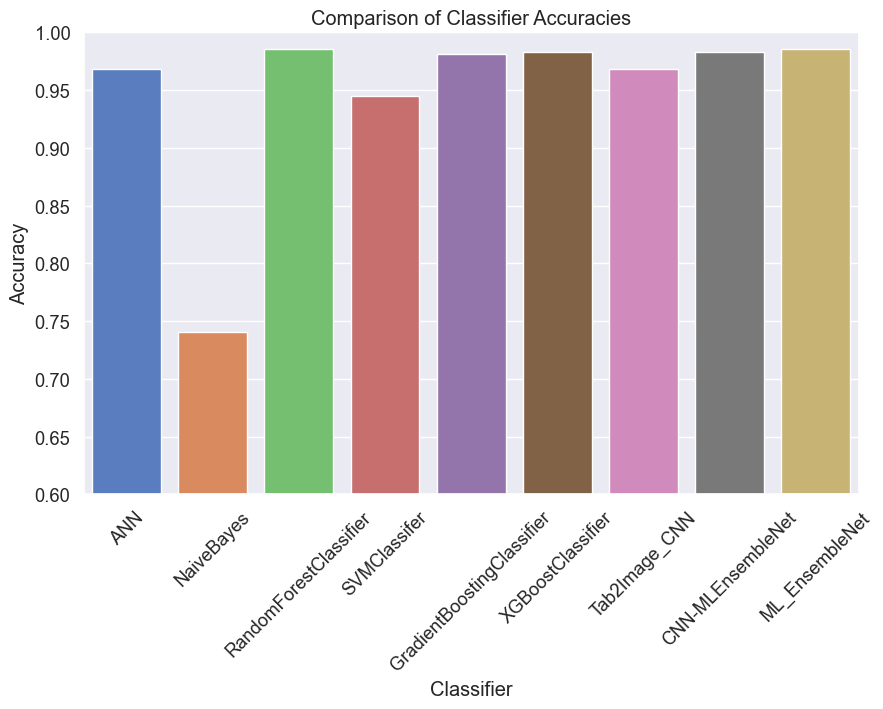

In [248]:
classifiers_series = pd.Series(models_list)

plt.figure(figsize=(10, 6)) 
sns.barplot(x=classifiers_series, y=accuracies, palette='muted', order=classifiers_series.unique())
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.title('Comparison of Classifier Accuracies')
plt.ylim(0.6, 1.0) 
plt.xticks(rotation=45)  
plt.show()

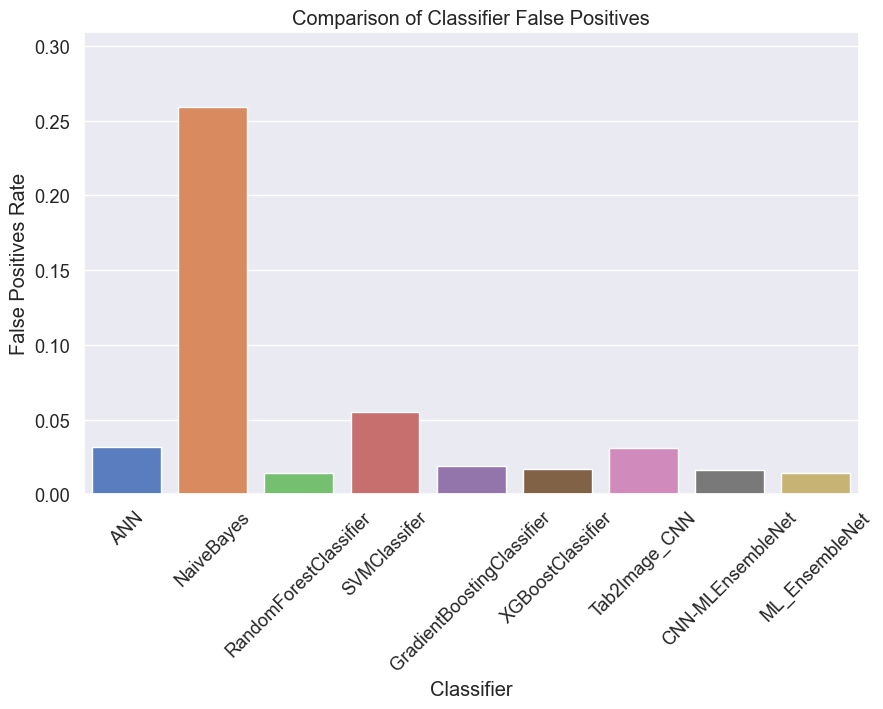

In [249]:
classifiers_series = pd.Series(models_list)

plt.figure(figsize=(10, 6)) 
sns.barplot(x=classifiers_series, y=false_positives, palette='muted', order=classifiers_series.unique())
plt.xlabel('Classifier')
plt.ylabel('False Positives Rate')
plt.title('Comparison of Classifier False Positives')
plt.ylim(0, max(false_positives) + 0.05)  # 👈 Adjusted to make bars visible
plt.xticks(rotation=45)  
plt.show()

In [250]:
import pickle
# Save to a file
with open('Dataset/model_metrics.pkl', 'wb') as f:
    pickle.dump({'accuracies': accuracies, 'false_positives': false_positives}, f)
